# Task-routed: within-phase screening **by task similarity** (Option A)

Loads `sim_*.npz` from **one or more** run folders, computes the same screening metrics as `nb_task_routed_within_phase_signal_test.ipynb`, and stratifies by **task similarity** parsed from participant IDs.

**Participant ID patterns** (see `a1b2.analysis.within_phase_screening`):
- Human batches: `study1_far_sub12`, `study2_near_sub3` → similarity = `far` / `near` / `same`
- Geometry phantoms: `geom_sub_same`, `geom_sub_far_1` → similarity from `geom_sub_*`

**Metrics:** B-phase (probe 1 = B-routed) hidden norm ratio, B loss/acc; A2 probe-0 vs probe-1 loss gap; `has_core_comms_keys`.

**Configure** `RUN_FOLDERS` or use auto-discovery below, then run all cells.


In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.analysis.within_phase_screening import (
    build_overview_long,
    discover_task_routed_folders,
    parse_task_similarity_from_participant,
    parse_study_cohort_from_participant,
)

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None

simulations_root = project_root / "data" / "simulations"
SIMILARITY_ORDER = ["same", "near", "far"]
COHORT_ORDER = ["study1", "study2", "geom", "unknown"]

plt.rcParams["figure.figsize"] = (10, 4)
print("Project root:", project_root)
print("Simulations root:", simulations_root)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations


## Configure run folders

- **`AUTO_DISCOVER_TASK_ROUTED`**: if `True`, scan `data/simulations/` for child folders whose name contains `task_routed` and contain `sim_*.npz`.
- Or set **`RUN_FOLDERS`** to a list of explicit `Path`s (strings OK).

Multiple folders typically correspond to different **hyperparameters** (e.g. sparsity); all rows get a `run_folder` column. Similarity always comes from **participant** id, not folder name.

**Performance:** scanning every `task_routed` folder and many `npz` files can take several minutes. For a quick check, set `AUTO_DISCOVER_TASK_ROUTED = False` and set `RUN_FOLDERS` to a **single** run directory.


In [2]:
# --- edit ---
AUTO_DISCOVER_TASK_ROUTED = True
RUN_FOLDERS = [
    # simulations_root / "two_module_rnn_25_task_routed_no_comms_nb2_nb2_task_routed_sp0_sep_cr_RNN",
]
# ----------------

if AUTO_DISCOVER_TASK_ROUTED:
    RUN_FOLDERS = discover_task_routed_folders(simulations_root)
    print(f"Discovered {len(RUN_FOLDERS)} task_routed folders under simulations")
    for p in RUN_FOLDERS[:15]:
        print(" ", p.name)
    if len(RUN_FOLDERS) > 15:
        print(f"  ... and {len(RUN_FOLDERS) - 15} more")
else:
    RUN_FOLDERS = [Path(p) if not isinstance(p, Path) else p for p in RUN_FOLDERS]
    RUN_FOLDERS = [simulations_root / p if not p.is_absolute() else p for p in RUN_FOLDERS]

RUN_FOLDERS = [p for p in RUN_FOLDERS if p.is_dir()]
if not RUN_FOLDERS:
    raise FileNotFoundError("No run folders configured or discovered.")


Discovered 52 task_routed folders under simulations
  two_module_rnn_25_task_routed_low_sparse_nb2_init0.01_nb2_task_routed_sp0.3_sep_cr_RNN_init0.01
  two_module_rnn_25_task_routed_low_sparse_nb2_init0.1_nb2_task_routed_sp0.3_sep_cr_RNN_init0.1
  two_module_rnn_25_task_routed_low_sparse_nb2_init0.3_nb2_task_routed_sp0.3_sep_cr_RNN_init0.3
  two_module_rnn_25_task_routed_low_sparse_nb2_init0.5_nb2_task_routed_sp0.3_sep_cr_RNN_init0.5
  two_module_rnn_25_task_routed_low_sparse_nb2_init0.7_nb2_task_routed_sp0.3_sep_cr_RNN_init0.7
  two_module_rnn_25_task_routed_low_sparse_nb2_nb2_task_routed_sp0.3_sep_cr_RNN
  two_module_rnn_25_task_routed_nb2_init0.01_nb2_task_routed_sp1_sep_cr_RNN_init0.01
  two_module_rnn_25_task_routed_nb2_init0.1_nb2_task_routed_sp1_sep_cr_RNN_init0.1
  two_module_rnn_25_task_routed_nb2_init0.3_nb2_task_routed_sp1_sep_cr_RNN_init0.3
  two_module_rnn_25_task_routed_nb2_init0.5_nb2_task_routed_sp1_sep_cr_RNN_init0.5
  two_module_rnn_25_task_routed_nb2_init0.7_nb2_task

## Build long table + QC

Rows with `task_similarity` is `NaN` could not be parsed — inspect and extend `parse_task_similarity_from_participant` if needed.


In [3]:
overview_long = build_overview_long(RUN_FOLDERS)

if "error" in overview_long.columns:
    bad = overview_long[overview_long["error"].notna()]
    if len(bad):
        print("Load errors:")
        display(bad[["run_folder", "participant", "error"]].head(20))

plot_df = overview_long[overview_long["error"].isna()].copy() if "error" in overview_long.columns else overview_long.copy()
if len(plot_df) == 0:
    raise RuntimeError("No valid npz rows (empty run folders or all load errors).")
print(f"Total rows (ok): {len(plot_df)} from {plot_df['run_folder'].nunique()} run folders")

unmatched = plot_df["task_similarity"].isna()
if unmatched.any():
    print(f"Unmatched similarity (n={unmatched.sum()}), sample participants:")
    display(plot_df.loc[unmatched, "participant"].drop_duplicates().head(25))
else:
    print("All participants matched to same/near/far.")

plot_df = plot_df.copy()
plot_df["task_similarity"] = pd.Categorical(
    plot_df["task_similarity"], categories=SIMILARITY_ORDER, ordered=True
)
plot_df["study_cohort"] = pd.Categorical(
    plot_df["study_cohort"], categories=COHORT_ORDER, ordered=True
)

display(plot_df.head(10))


Total rows (ok): 13407 from 52 run folders
All participants matched to same/near/far.


,participant,path,b_n_valid,b_n_probe_0,b_n_probe_1,b_median_hA_over_hB_all,b_median_hA_over_hB_probe1,b_mean_loss_probe1,b_mean_acc_probe1,a2_mean_loss_probe0,a2_mean_acc_probe0,a2_mean_loss_probe1,a2_mean_acc_probe1,a2_loss_gap_p1_minus_p0,has_core_comms_keys,run_folder,run_folder_path,task_similarity,study_cohort
0,study1_far_sub1,sim_study1_far_sub1.npz,12000,6000,6000,1307.645996,0.000287,0.008998,0.995872,0.000344,0.999857,0.173524,0.839596,0.173180,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
1,study1_far_sub10,sim_study1_far_sub10.npz,12000,6000,6000,1056.027344,0.000278,0.008009,0.995931,0.000359,0.999696,0.156373,0.843357,0.156014,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
2,study1_far_sub12,sim_study1_far_sub12.npz,12000,6000,6000,1549.507080,0.000299,0.008174,0.997144,0.000373,0.999663,0.144053,0.925660,0.143680,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
3,study1_far_sub13,sim_study1_far_sub13.npz,12000,6000,6000,1745.304443,0.000403,0.008153,0.996873,0.000355,0.999748,0.146601,0.894728,0.146246,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
4,study1_far_sub15,sim_study1_far_sub15.npz,12000,6000,6000,1723.685059,0.000280,0.009106,0.995110,0.000354,0.999825,0.187854,0.821696,0.187500,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
5,study1_far_sub16,sim_study1_far_sub16.npz,12000,6000,6000,1523.456421,0.000386,0.009960,0.994037,0.000385,0.999757,0.170386,0.814299,0.170002,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
6,study1_far_sub19,sim_study1_far_sub19.npz,12000,6000,6000,1334.227051,0.000287,0.008349,0.996895,0.000367,0.999792,0.142819,0.920197,0.142451,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
7,study1_far_sub22,sim_study1_far_sub22.npz,12000,6000,6000,1388.597168,0.000255,0.008321,0.996087,0.000348,0.999860,0.155204,0.852793,0.154856,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
8,study1_far_sub25,sim_study1_far_sub25.npz,12000,6000,6000,1654.783325,0.000359,0.008313,0.996016,0.000382,0.999741,0.156193,0.875595,0.155811,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1
9,study1_far_sub26,sim_study1_far_sub26.npz,12000,6000,6000,1426.009033,0.000283,0.008098,0.996848,0.000344,0.999835,0.157661,0.831115,0.157317,True,two_module_rnn_25_task_routed_low_sparse_nb2_i...,/home/kat/workspace/Structure-Function-Analysi...,far,study1


## Counts: similarity × cohort × run folder


In [4]:
ct = (
    plot_df.groupby(["task_similarity", "study_cohort"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)
display(ct.pivot_table(index="task_similarity", columns="study_cohort", values="n", aggfunc="sum", fill_value=0))

print("Rows per run_folder:")
display(plot_df.groupby("run_folder").size().sort_values(ascending=False).head(25))


/tmp/ipykernel_2662416/2107515614.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(["task_similarity", "study_cohort"], dropna=False)
/tmp/ipykernel_2662416/2107515614.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(ct.pivot_table(index="task_similarity", columns="study_cohort", values="n", aggfunc="sum", fill_value=0))


study_cohort,study1,study2,geom,unknown
task_similarity,,,,
same,2205,2293,0,0
near,2314,2275,0,0
far,2118,2202,0,0


Rows per run_folder:


run_folder
two_module_rnn_25_task_routed_sp05_nb2_init0.5_nb2_task_routed_sp0.5_sep_cr_RNN_init0.5          305
two_module_rnn_25_task_routed_no_comms_nb2_init0.1_nb2_task_routed_sp0_sep_cr_RNN_init0.1        305
two_module_rnn_25_task_routed_sp05_nb2_nb2_task_routed_sp0.5_sep_cr_RNN                          305
two_module_rnn_25_task_routed_sp05_nb2_init0.7_nb2_task_routed_sp0.5_sep_cr_RNN_init0.7          305
two_module_rnn_25_task_routed_low_sparse_nb2_init0.1_nb2_task_routed_sp0.3_sep_cr_RNN_init0.1    305
two_module_rnn_25_task_routed_sp09_nb2_init0.7_nb2_task_routed_sp0.9_sep_cr_RNN_init0.7          305
two_module_rnn_25_task_routed_sp05_nb2_init0.1_nb2_task_routed_sp0.5_sep_cr_RNN_init0.1          305
two_module_rnn_25_task_routed_sp07_nb2_init0.5_nb2_task_routed_sp0.7_sep_cr_RNN_init0.5          305
two_module_rnn_25_task_routed_sp01_nb2_nb2_task_routed_sp0.1_sep_cr_RNN                          305
two_module_rnn_25_task_routed_sp09_nb2_nb2_task_routed_sp0.9_sep_cr_RNN         

## Summary statistics by task similarity

Key columns for comms screening: **`b_median_hA_over_hB_probe1`**, **`a2_loss_gap_p1_minus_p0`**.


In [5]:
metric_cols = [
    "b_median_hA_over_hB_probe1",
    "b_median_hA_over_hB_all",
    "b_mean_loss_probe1",
    "b_mean_acc_probe1",
    "a2_loss_gap_p1_minus_p0",
    "a2_mean_loss_probe0",
    "a2_mean_loss_probe1",
]
metric_cols = [c for c in metric_cols if c in plot_df.columns]

g = plot_df.dropna(subset=["task_similarity"]).groupby("task_similarity", observed=True)
display(g[metric_cols].agg(["count", "mean", "std", "median"]).T)


task_similarity                            same          near           far
b_median_hA_over_hB_probe1 count   4.498000e+03  4.589000e+03  4.320000e+03
                           mean    4.968834e-02  4.924174e-02  4.938303e-02
                           std     6.301180e-02  6.286706e-02  6.378295e-02
                           median  1.741819e-02  1.664786e-02  1.566011e-02
b_median_hA_over_hB_all    count   4.498000e+03  4.589000e+03  4.320000e+03
                           mean    5.397697e+06  5.260439e+06  5.498909e+06
                           std     1.238598e+07  1.223837e+07  1.246218e+07
                           median  2.303766e+01  2.429741e+01  2.522114e+01
b_mean_loss_probe1         count   4.498000e+03  4.589000e+03  4.320000e+03
                           mean    8.013702e-03  8.042535e-03  8.027648e-03
                           std     1.025816e-03  9.910746e-04  1.011829e-03
                           median  8.155184e-03  8.192323e-03  8.162209e-03
b_mean_acc_probe1          count   4.498000e+03  4.589000e+03  4.320000e+03
                           mean    9.957329e-01  9.956469e-01  9.956510e-01
                           std     1.143174e-03  1.073568e-03  1.101900e-03
                           median  9.958697e-01  9.957567e-01  9.958101e-01
a2_loss_gap_p1_minus_p0    count   4.498000e+03  4.589000e+03  4.320000e+03
                           mean    1.453624e-01  1.468853e-01  1.491705e-01
                           std     2.732419e-02  2.605889e-02  2.768167e-02
                           median  1.482121e-01  1.488736e-01  1.517198e-01
a2_mean_loss_probe0        count   4.498000e+03  4.589000e+03  4.320000e+03
                           mean    3.207260e-04  3.230249e-04  3.187717e-04
                           std     8.760111e-05  9.052006e-05  8.532264e-05
                           median  3.337319e-04  3.369989e-04  3.319752e-04
a2_mean_loss_probe1        count   4.498000e+03  4.589000e+03  4.320000e+03
                           mean    1.456832e-01  1.472083e-01  1.494893e-01
                           std     2.733432e-02  2.606822e-02  2.768619e-02
                           median  1.485398e-01  1.492034e-01  1.520628e-01

## Figures: distributions by similarity


/tmp/ipykernel_2662416/98446128.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2662416/98446128.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2662416/98446128.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2662416/98446128.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


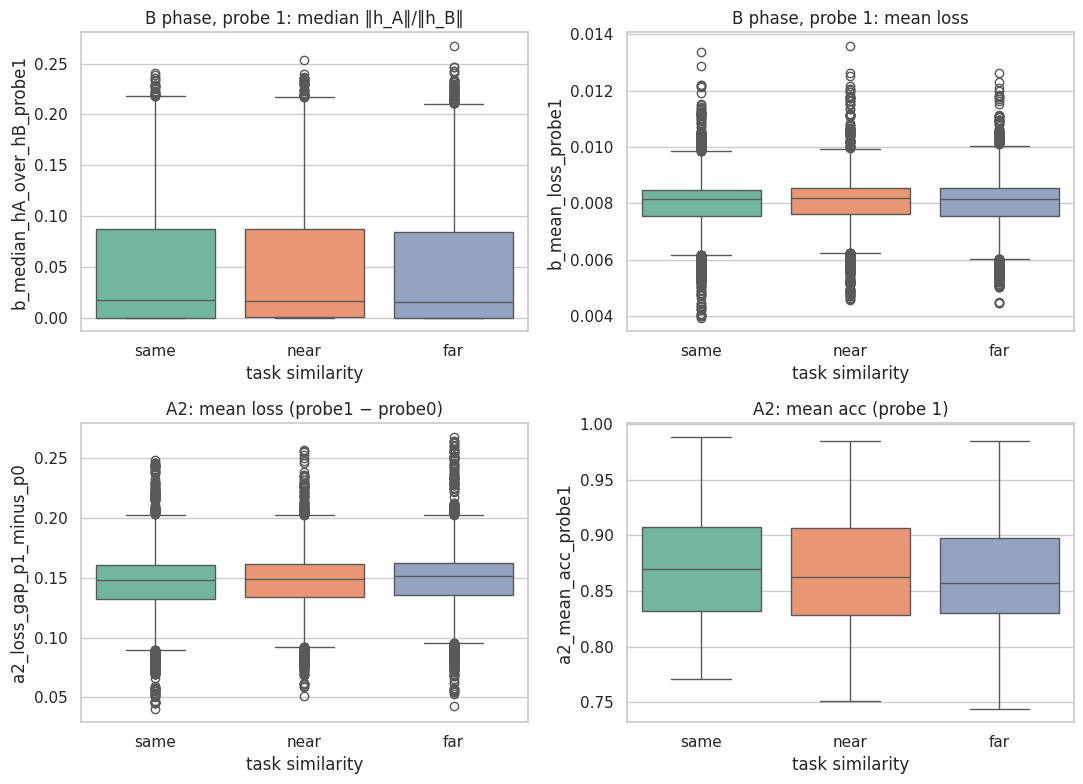

In [6]:
dfp = plot_df.dropna(subset=["task_similarity"]).copy()

def box_by_similarity(y, ax, title):
    if dfp[y].notna().sum() == 0:
        ax.set_title(f"{title}\n(no data)")
        return
    if sns is not None:
        sns.boxplot(
            data=dfp,
            x="task_similarity",
            y=y,
            order=SIMILARITY_ORDER,
            ax=ax,
            palette="Set2",
        )
    else:
        data = [dfp.loc[dfp["task_similarity"] == s, y].dropna().values for s in SIMILARITY_ORDER if (dfp["task_similarity"] == s).any()]
        labels = [s for s in SIMILARITY_ORDER if (dfp["task_similarity"] == s).any()]
        if data:
            ax.boxplot(data, labels=labels)
    ax.set_title(title)
    ax.set_xlabel("task similarity")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
box_by_similarity("b_median_hA_over_hB_probe1", axes[0, 0], "B phase, probe 1: median ‖h_A‖/‖h_B‖")
box_by_similarity("b_mean_loss_probe1", axes[0, 1], "B phase, probe 1: mean loss")
box_by_similarity("a2_loss_gap_p1_minus_p0", axes[1, 0], "A2: mean loss (probe1 − probe0)")
box_by_similarity("a2_mean_acc_probe1", axes[1, 1], "A2: mean acc (probe 1)")
plt.tight_layout()
plt.show()


### Optional: hue by study cohort (study1 vs study2 vs geom)

Only useful when multiple cohorts appear **within** the same similarity level.


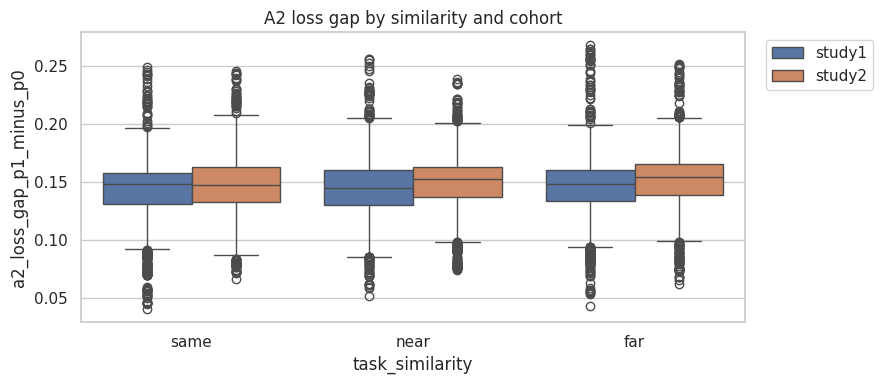

In [7]:
dfp2 = plot_df.dropna(subset=["task_similarity"]).copy()
if dfp2["study_cohort"].nunique() > 1 and sns is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.boxplot(
        data=dfp2,
        x="task_similarity",
        y="a2_loss_gap_p1_minus_p0",
        hue="study_cohort",
        order=SIMILARITY_ORDER,
        hue_order=[c for c in COHORT_ORDER if c in set(dfp2["study_cohort"].astype(str))],
        ax=ax,
    )
    ax.set_title("A2 loss gap by similarity and cohort")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Skip cohort hue: single cohort or seaborn missing.")


## Save table for other notebooks / figures


In [8]:
out_csv = project_root / "data" / "derived" / "within_phase_overview_by_similarity.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
overview_long.to_csv(out_csv, index=False)
print("Wrote:", out_csv)


Wrote: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/derived/within_phase_overview_by_similarity.csv


## Interpretation notes

- **Similarity** is read from the **participant** string, not the run folder. If one run only contains `study1_far_sub*`, all rows will be `far` — compare **across run folders** (e.g. sparsity) with `run_folder` as a second factor.
- **`b_median_hA_over_hB_probe1`**: use **probe 1** for B-routed input; mixed-probe "all" metrics are misleading when both probes appear in the B block.
- **No shift by similarity** may mean the metric is weak, power is low, or geometry mainly affects outcomes you have not merged yet (e.g. transfer from the interference notebook).
- **`has_core_comms_keys`**: if all `False`, regenerate sims with post-phase core/comms saving for pathway-level follow-up.
